# Freight rate assessment: results review

Review the saved experiments, October evaluation, final models and submission outputs. This notebook **does not fit or tune models**. It reads the existing results and can reproduce predictions from the saved models to check their consistency.

Run cells from top to bottom using the Spotter `.venv` kernel. Finish notebooks 1 and 2 and run the training, prediction and scoring scripts before this notebook.

The model-selection metrics, October holdout metrics and unlabeled submission predictions represent different stages. The provider's hidden validation accuracy is unavailable locally.


In [1]:
from pathlib import Path
import sys
import json
import hashlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image, Markdown

PROJECT_DIR = None  # Set Path('/your/path/Spotter') if the automatic lookup fails.
candidates = ([Path(PROJECT_DIR).expanduser()] if PROJECT_DIR is not None
              else [Path.cwd(), *Path.cwd().parents, Path.home() / 'Projects' / 'Spotter'])
ROOT = next((p.resolve() for p in candidates if (p / 'src/train.py').is_file()
             and (p / 'outputs/training/training_report.json').is_file()), None)
if ROOT is None:
    raise FileNotFoundError('Set PROJECT_DIR to Spotter and run python -m src.train first.')
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.data import find_file
from src.train import load_model, sha256_file
from src.predict import load_prediction_inputs, make_submission, validate_submission
from src.predict_december import make_december_predictions
from score import validate_december as validate_completed_december

CHECK_MODEL_PREDICTIONS = True  # Inference only; no model fitting or new evaluation.
SAVE_REVIEW_OUTPUTS = False  # Optional exports; existing results are never overwritten.
REVIEW_DIR = ROOT / 'outputs' / 'results_review'
review_figures = {}

pd.set_option('display.max_columns', 20)
plt.rcParams.update({'figure.figsize': (10, 4), 'axes.spines.top': False,
                     'axes.spines.right': False, 'axes.grid': True, 'grid.alpha': 0.2})
print('Reviewing:', ROOT)


Reviewing: /Users/wijamuni/Projects/Spotter


## 1. Load the saved results

Missing files mean the relevant earlier step needs to be completed. Repeated runs of this review do not re-evaluate October or retrain the final models. The review uses saved, frozen October predictions.


In [2]:
paths = {
    'comparison': ROOT / 'outputs/model_experiments/model_comparison.csv',
    'folds': ROOT / 'outputs/model_experiments/fold_metrics.csv',
    'oof': ROOT / 'outputs/model_experiments/out_of_fold_predictions.csv',
    'masked': ROOT / 'outputs/model_experiments/missing_signal_diagnostics.csv',
    'training': ROOT / 'outputs/training/training_report.json',
    'holdout_metrics': ROOT / 'outputs/training/holdout_metrics.json',
    'holdout_predictions': ROOT / 'outputs/training/holdout_predictions.csv',
    'quality': ROOT / 'outputs/training/data_quality_report.csv',
    'submission': ROOT / 'outputs/validation_predictions.csv',
    'december': ROOT / 'outputs/december_predictions.csv',
    'chart': ROOT / 'outputs/candidate_december.png',
}
missing = [str(path) for path in paths.values() if not path.is_file()]
if missing:
    raise FileNotFoundError('Complete the earlier scripts; missing: ' + ', '.join(missing))

comparison = pd.read_csv(paths['comparison'])
fold_metrics = pd.read_csv(paths['folds'])
oof = pd.read_csv(paths['oof'], parse_dates=['date'])
masked = pd.read_csv(paths['masked'])
training_report = json.loads(paths['training'].read_text())
holdout_report = json.loads(paths['holdout_metrics'].read_text())
holdout_predictions = pd.read_csv(paths['holdout_predictions'], parse_dates=['date'])
quality = pd.read_csv(paths['quality'])
submission = pd.read_csv(paths['submission'], dtype={'load_id': 'string'})
december = pd.read_csv(paths['december'])
selection = training_report['selection']
MAIN_NAME = selection['main']['name']
SCENARIO_NAME = selection['december_scenario']['name']
HOLDOUT_START = pd.Timestamp(selection['holdout_start'])
metrics = pd.DataFrame(holdout_report['metrics']).T
for column in ['rows', 'mae', 'rmse', 'bias']:
    metrics[column] = pd.to_numeric(metrics[column])
display(pd.DataFrame([{'artifact': name, 'size_kb': round(path.stat().st_size/1024, 1)}
                      for name, path in paths.items()]))


,artifact,size_kb
0,comparison,0.7
1,folds,3.3
2,oof,15308.3
3,masked,1.6
4,training,4.0
5,holdout_metrics,2.4
6,holdout_predictions,1538.4
7,quality,0.3
8,submission,209.1
9,december,1.8


## 2. Verify that the review uses matching results

Check the training/holdout fingerprint, saved model files and development-data checksum. Verify error calculations independently from the saved predictions. Code hashes can differ if implementation files were edited afterward; a mismatch needs explanation before the results are reported as belonging to the current code.


In [3]:
assert training_report['fingerprint'] == holdout_report['fingerprint'], 'Training and holdout reports differ.'
assert sha256_file(find_file(ROOT, 'development')) == holdout_report['signature']['development_sha256'], 'Development data changed.'
for filename, key in [('data.py', 'data_code_sha256'), ('features.py', 'features_code_sha256'),
                       ('train.py', 'training_code_sha256')]:
    assert sha256_file(ROOT / 'src' / filename) == holdout_report['signature'][key], f'{filename} changed after training.'
model_paths = {'main': ROOT / 'models/main_model.joblib',
               'december_scenario': ROOT / 'models/december_model.joblib'}
for role, path in model_paths.items():
    assert path.is_file(), f'Missing model: {path}'
    assert sha256_file(path) == training_report['artifacts'][role]['sha256'], f'{role} model changed.'

assert oof.date.max() < HOLDOUT_START
assert not oof.duplicated(['experiment', 'load_id']).any()
for experiment, group in oof.groupby('experiment'):
    saved = comparison.set_index('experiment').loc[experiment]
    error = group.predicted_rate.to_numpy() - group.actual_rate.to_numpy()
    assert np.isfinite(error).all()
    assert len(group) == int(saved.evaluation_rows)
    assert np.isclose(np.abs(error).mean(), saved.pooled_mae)
    assert np.isclose(np.sqrt(np.square(error).mean()), saved.pooled_rmse)

assert set(holdout_predictions.role) == {'main', 'december_scenario'}
assert holdout_predictions.date.min() >= HOLDOUT_START
assert holdout_predictions.date.max() == pd.Timestamp(holdout_report['holdout_last_date'])
verified_metrics = []
for role, group in holdout_predictions.groupby('role'):
    assert group.load_id.is_unique
    assert group.experiment.eq(selection[role]['name']).all()
    truth, prediction = group.actual_rate.to_numpy(), group.predicted_rate.to_numpy()
    assert np.isfinite(truth).all() and np.isfinite(prediction).all() and (prediction > 0).all()
    error = prediction - truth
    measured = {'role': role, 'rows': len(group), 'mae': np.abs(error).mean(),
                'rmse': np.sqrt(np.square(error).mean()), 'bias': error.mean(),
                'median_absolute_error': np.median(np.abs(error)),
                'p95_absolute_error': np.quantile(np.abs(error), 0.95)}
    for field in ['rows', 'mae', 'rmse', 'bias']:
        assert np.isclose(measured[field], metrics.loc[role, field]), f'{role}: {field} mismatch'
    verified_metrics.append(measured)
verified_metrics = pd.DataFrame(verified_metrics).set_index('role')
print('Artifact checksums and independently recomputed metrics match.')
display(verified_metrics.round(2))


Artifact checksums and independently recomputed metrics match.


,rows,mae,rmse,bias,median_absolute_error,p95_absolute_error
role,,,,,,
december_scenario,4853,145.86,647.63,42.04,60.75,294.94
main,4853,137.94,647.45,33.57,54.70,260.34


## 3. Explain the development and evaluation sequence

Model comparison uses expanding time folds before October. The frozen choices are evaluated on October, then final models are fitted on all development rows. The final prediction CSV has no ground-truth rate column.


In [4]:
selection_months = sorted(fold_metrics.month.unique())
timeline = pd.DataFrame([
    {'stage': 'Model selection', 'period': ', '.join(selection_months),
     'rows': int(comparison.evaluation_rows.iloc[0]), 'purpose': 'Compare candidates using earlier expanding folds'},
    {'stage': 'Frozen holdout', 'period': f"{holdout_report['holdout_first_date']} to {holdout_report['holdout_last_date']}",
     'rows': int(holdout_report['holdout_rows']), 'purpose': 'Assess fixed choices before final refitting'},
    {'stage': 'Final model fitting', 'period': 'All labeled development dates',
     'rows': int(training_report['final_training_rows']), 'purpose': 'Fit saved models used for submission'},
    {'stage': 'Submission predictions', 'period': 'Unlabeled final inputs',
     'rows': len(submission), 'purpose': 'Provider computes hidden accuracy after submission'},
])
display(timeline)
display(pd.DataFrame([{'role': role, 'model': training_report['artifacts'][role]['experiment'],
                       'features': len(training_report['artifacts'][role]['feature_columns']),
                       **training_report['artifacts'][role]['feature_config']}
                      for role in model_paths]))


,stage,period,rows,purpose
0,Model selection,"2025-07, 2025-08, 2025-09",14341,Compare candidates using earlier expanding folds
1,Frozen holdout,2025-10-01 to 2025-10-31,4853,Assess fixed choices before final refitting
2,Final model fitting,All labeled development dates,48000,Fit saved models used for submission
3,Submission predictions,Unlabeled final inputs,12000,Provider computes hidden accuracy after submis...


,role,model,features,include_market_index,include_quote_signal,include_geography
0,main,catboost_full_per_mile,21,True,True,False
1,december_scenario,catboost_scenario_per_mile,17,False,False,False


## 4. Model-selection performance

MAE is average absolute total-dollar error. RMSE gives large errors more weight. These values are pooled over the model-selection months, not the October holdout. The percentage improvement below refers only to comparison against the baseline on those same selection rows.


In [5]:
display(comparison[['experiment', 'evaluation_rows', 'pooled_mae', 'pooled_rmse', 'fold_mae_std']].round(2))
baseline_mae = float(comparison.set_index('experiment').loc['equipment_baseline', 'pooled_mae'])
main_cv_mae = float(comparison.set_index('experiment').loc[MAIN_NAME, 'pooled_mae'])
improvement = 100 * (baseline_mae-main_cv_mae)/baseline_mae
print(f'Selected main approach: {MAIN_NAME}')
print(f'Model-selection MAE improvement versus baseline: {improvement:.1f}%')
fig, ax = plt.subplots(figsize=(11, 5))
ordered = comparison.sort_values('pooled_mae')
colors = ['#064A56' if name == MAIN_NAME else '#9BBAC0' for name in ordered.experiment]
ax.barh(ordered.experiment, ordered.pooled_mae, color=colors)
ax.invert_yaxis()
ax.set(xlabel='Pooled MAE ($)', title='Earlier chronological folds: model comparison')
fig.tight_layout()
review_figures['model_comparison'] = fig
plt.show()
display(fold_metrics.pivot(index='month', columns='experiment', values='mae').round(2))


,experiment,evaluation_rows,pooled_mae,pooled_rmse,fold_mae_std
0,catboost_full_per_mile,14341,133.27,624.48,22.00
1,catboost_without_quote,14341,144.61,629.10,52.03
2,catboost_scenario_per_mile,14341,147.94,630.36,55.91
3,catboost_full_total,14341,163.44,636.64,41.97
4,ridge_full_per_mile,14341,171.70,640.50,59.37
5,ridge_scenario_per_mile,14341,188.52,646.82,69.15
6,equipment_baseline,14341,225.82,662.00,15.80


Selected main approach: catboost_full_per_mile
Model-selection MAE improvement versus baseline: 41.0%


/var/folders/_8/bfqkrfws0gj8nq517f02t3lr0000gn/T/ipykernel_6651/344039649.py:15: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


experiment,catboost_full_per_mile,catboost_full_total,catboost_scenario_per_mile,catboost_without_quote,equipment_baseline,ridge_full_per_mile,ridge_scenario_per_mile
month,,,,,,,
2025-07,149.03,207.63,211.61,203.84,209.59,233.16,252.74
2025-08,141.94,156.08,115.32,114.64,241.11,114.90,115.12
2025-09,107.87,124.47,114.22,112.83,227.32,164.93,195.77


## 5. October performance and error concentration

Positive bias means the average prediction exceeds the actual rate. Compare mean absolute error with the median to understand the tail of the error distribution. The largest-error rows remain in all metrics and training data; no outliers are silently removed.


In [6]:
main_holdout = holdout_predictions.loc[holdout_predictions.role.eq('main')].copy()
main_holdout['error'] = main_holdout.predicted_rate-main_holdout.actual_rate
main_holdout['absolute_error'] = np.abs(main_holdout.error)
main_holdout['squared_error'] = np.square(main_holdout.error)
tail_n = max(1, int(np.ceil(len(main_holdout)*0.01)))
total_squared_error = main_holdout.squared_error.sum()
tail_share = (100*main_holdout.nlargest(tail_n, 'squared_error').squared_error.sum()/total_squared_error
              if total_squared_error > 0 else 0.0)
print(f'The {tail_n} largest-error rows (approximately 1%) contribute {tail_share:.1f}% of squared error.')
display(main_holdout.nlargest(10, 'absolute_error')[
    ['load_id', 'date', 'pickup', 'delivery', 'equipment', 'distance',
     'actual_rate', 'predicted_rate', 'absolute_error']].round(2))
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].scatter(main_holdout.actual_rate, main_holdout.predicted_rate, s=8, alpha=0.22, color='#064A56')
upper = max(main_holdout.actual_rate.max(), main_holdout.predicted_rate.max())
axes[0].plot([0, upper], [0, upper], '--', color='#B33A3A')
axes[0].set(xlabel='Actual rate ($)', ylabel='Predicted rate ($)', title='October holdout: all loads')
axes[1].scatter(main_holdout.predicted_rate, main_holdout.error, s=8, alpha=0.22, color='#064A56')
axes[1].axhline(0, linestyle='--', color='#B33A3A')
axes[1].set(xlabel='Predicted rate ($)', ylabel='Prediction minus actual ($)', title='October residuals')
fig.tight_layout()
review_figures['holdout_diagnostics'] = fig
plt.show()


The 49 largest-error rows (approximately 1%) contribute 95.2% of squared error.


,load_id,date,pickup,delivery,equipment,distance,actual_rate,predicted_rate,absolute_error
392,TR-043540,2025-10-03,Milwaukee,Bakersfield,Dry Van,1893.0,17514.11,3795.03,13719.08
3066,TR-046214,2025-10-20,Columbia,Tucson,Flatbed,2023.4,17893.17,4267.06,13626.11
4151,TR-047299,2025-10-27,Boston,Bakersfield,Reefer,2979.1,19110.30,6148.53,12961.77
3369,TR-046517,2025-10-22,Toledo,Albuquerque,Reefer,1684.3,14784.38,3772.73,11011.65
3219,TR-046367,2025-10-21,Bakersfield,Columbia,Dry Van,2251.9,14403.14,4598.32,9804.82
1120,TR-044268,2025-10-08,Albany,Albuquerque,Dry Van,2492.6,14425.42,4652.03,9773.39
4389,TR-047537,2025-10-29,Los Angeles,Richmond,Dry Van,2782.4,15003.55,5274.41,9729.14
155,TR-043303,2025-10-01,Atlanta,Phoenix,Reefer,2083.1,13894.55,4570.59,9323.96
237,TR-043385,2025-10-02,Lexington,Lubbock,Dry Van,1187.0,11696.44,2470.77,9225.67
4439,TR-047587,2025-10-29,Corpus Christi,Las Vegas,Flatbed,1383.3,11596.28,2998.04,8598.24


/var/folders/_8/bfqkrfws0gj8nq517f02t3lr0000gn/T/ipykernel_6651/313118779.py:23: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## 6. October errors by shipment segment

Use row counts alongside each segment's errors. The missing-weight subgroup is small, so its average error has limited precision. These tables explain performance; they are not used to change the frozen models.


In [7]:
main_holdout['distance_band'] = pd.cut(main_holdout.distance, [0, 250, 750, 1500, np.inf],
                                      labels=['0-250', '250-750', '750-1500', '1500+'])
main_holdout['weight_missing'] = main_holdout.weight.isna()
segment_tables = {}
for column in ['equipment', 'distance_band', 'weight_missing']:
    table = main_holdout.groupby(column, observed=True, dropna=False).agg(
        rows=('absolute_error', 'size'), mae=('absolute_error', 'mean'),
        mean_squared_error=('squared_error', 'mean'))
    table['rmse'] = np.sqrt(table.pop('mean_squared_error'))
    segment_tables[column] = table
    print(column)
    display(table.round(2))
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, column, title in [(axes[0], 'equipment', 'Equipment'), (axes[1], 'distance_band', 'Distance (miles)')]:
    table = segment_tables[column]
    ax.bar(table.index.astype(str), table.mae, color='#176B87')
    ax.set(title=title, ylabel='October MAE ($)')
fig.tight_layout()
review_figures['segment_errors'] = fig
plt.show()


equipment


,rows,mae,rmse
equipment,,,
Dry Van,2745,134.48,618.93
Flatbed,918,145.35,639.63
Reefer,1190,140.20,714.34


distance_band


,rows,mae,rmse
distance_band,,,
0-250,290,38.45,143.00
250-750,1556,71.85,310.83
750-1500,1643,129.89,588.47
1500+,1364,244.17,979.67


weight_missing


,rows,mae,rmse
weight_missing,,,
False,4788,138.55,651.45
True,65,93.12,191.82


/var/folders/_8/bfqkrfws0gj8nq517f02t3lr0000gn/T/ipykernel_6651/3491683040.py:20: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## 7. Data quality and feature availability

Quality-report counts can overlap: nonpositive weights converted to missing are included in the final missing-weight count. CatBoost handles numerical missing values natively; the Ridge comparisons used training-only median imputation. Geographic inputs were excluded from the selected models.

The main approach uses market and quote signals. Their availability at prediction time remains an assumption recorded in the saved model selection. Explain it in the report. The separate December model excludes those inputs during fitting and prediction.


In [8]:
display(quality)
print('Recorded signal-availability note:', training_report.get('signal_availability', 'Unverified'))
masked_summary = masked.groupby('experiment').agg(
    rows=('rows', 'sum'), absolute_error_sum=('absolute_error_sum', 'sum'),
    squared_error_sum=('squared_error_sum', 'sum'))
masked_summary['mae_without_market_or_quote'] = masked_summary.absolute_error_sum/masked_summary.rows
masked_summary['rmse_without_market_or_quote'] = np.sqrt(masked_summary.squared_error_sum/masked_summary.rows)
display(masked_summary[['rows', 'mae_without_market_or_quote', 'rmse_without_market_or_quote']].round(2))
main_masked_mae = float(masked_summary.loc[MAIN_NAME, 'mae_without_market_or_quote'])
print(f'Main approach with both signals absent: selection-fold MAE=${main_masked_mae:,.2f}.')


,dataset,column,issue,rows
0,development,weight,nonpositive weight converted to missing,292
1,development,weight,missing after cleaning,592
2,development,market_index,missing after cleaning,374
3,validation,weight,nonpositive weight converted to missing,145
4,validation,weight,missing after cleaning,310
5,validation,market_index,missing after cleaning,249


Recorded signal-availability note: Confirm quote_signal and market_index availability before final model choice.


,rows,mae_without_market_or_quote,rmse_without_market_or_quote
experiment,,,
catboost_full_per_mile,14341,405.18,781.75
catboost_full_total,14341,189.11,646.45
catboost_without_quote,14341,130.60,624.90
ridge_full_per_mile,14341,158.48,635.29


Main approach with both signals absent: selection-fold MAE=$405.18.


## 8. Check the final prediction files

Validate exact submission columns, all 12,000 IDs, template order and finite positive rates. Verify the 31 December dates and fixed inputs using the supplied scorer's checks. These checks establish valid file structure, not hidden-label accuracy.


In [9]:
validate_submission(submission)
validation_inputs, template = load_prediction_inputs(ROOT)
assert submission.load_id.tolist() == template.load_id.tolist(), 'Submission does not match template row order.'
december_sorted = validate_completed_december(december)
assert len(december_sorted) == 31
display(pd.DataFrame([
    {'file': 'validation_predictions.csv', 'rows': len(submission),
     'minimum_rate': submission.predicted_rate.min(), 'median_rate': submission.predicted_rate.median(),
     'maximum_rate': submission.predicted_rate.max()},
    {'file': 'december_predictions.csv', 'rows': len(december),
     'minimum_rate': december.predicted_rate.min(), 'median_rate': december.predicted_rate.median(),
     'maximum_rate': december.predicted_rate.max()},
]).round(2))

if CHECK_MODEL_PREDICTIONS:
    main_bundle = load_model(model_paths['main'])
    scenario_bundle = load_model(model_paths['december_scenario'])
    expected_submission, _ = make_submission(validation_inputs, template, main_bundle)
    source_december = pd.read_csv(find_file(ROOT, 'december'))
    expected_december, _ = make_december_predictions(source_december, scenario_bundle)
    assert np.allclose(submission.predicted_rate, expected_submission.predicted_rate, rtol=0, atol=1e-8)
    actual_by_date = december.set_index('date').predicted_rate
    expected_by_date = expected_december.set_index('date').predicted_rate
    assert np.allclose(actual_by_date.loc[expected_by_date.index], expected_by_date, rtol=0, atol=1e-8)
    print('Both saved prediction CSVs match inference from their saved models, rounded to cents.')
print('Submission and December file checks passed.')


,file,rows,minimum_rate,median_rate,maximum_rate
0,validation_predictions.csv,12000,179.27,2051.96,7032.78
1,december_predictions.csv,31,841.89,853.55,867.56


Both saved prediction CSVs match inference from their saved models, rounded to cents.
Submission and December file checks passed.


## 9. Required December chart and route coverage

Display the existing chart generated by `score.py`. Only date varies in the fixed scenario. Its prices are model predictions; no actual December rates are available for this scenario.

The route counts below match city pair and equipment only. They may have different distances or weights, so even these small samples do not directly validate the exact fixed December load.


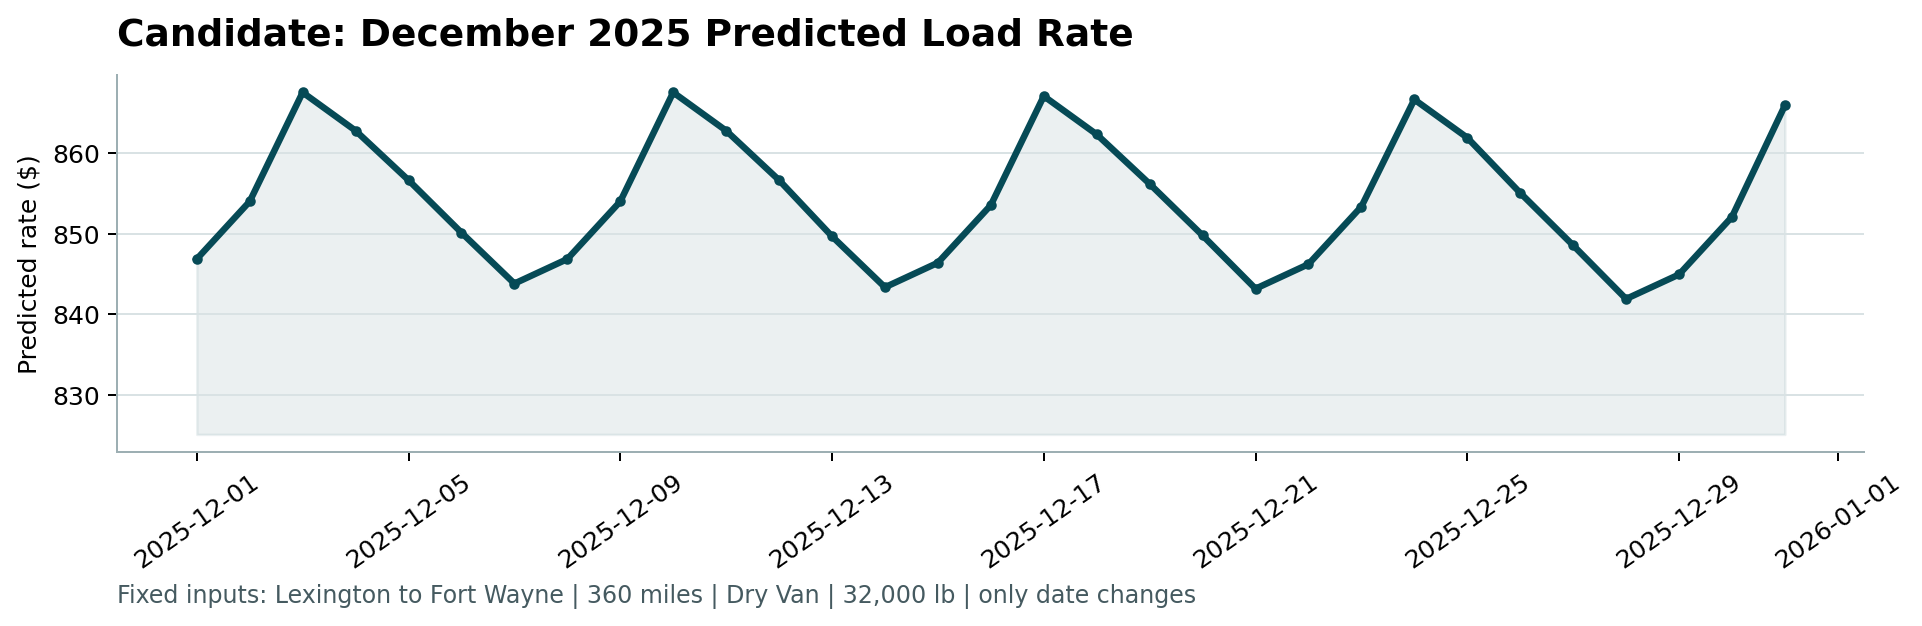

,evaluation_stage,same_route_and_equipment_rows,route_mae
0,Earlier selection folds,3,23.83
1,October holdout,3,39.94


,date,predicted_rate
0,2025-12-01,846.85
1,2025-12-02,854.01
2,2025-12-03,867.56
3,2025-12-04,862.80
4,2025-12-05,856.65
5,2025-12-06,850.13
6,2025-12-07,843.80


December prediction range: $841.89 to $867.56.


In [10]:
display(Image(filename=str(paths['chart']), width=1100))
route_evidence = []
for label, frame in [
    ('Earlier selection folds', oof.loc[oof.experiment.eq(SCENARIO_NAME)]),
    ('October holdout', holdout_predictions.loc[holdout_predictions.role.eq('december_scenario')]),
]:
    route = frame.loc[frame.pickup.eq('Lexington') & frame.delivery.eq('Fort Wayne')
                     & frame.equipment.eq('Dry Van')]
    route_evidence.append({'evaluation_stage': label, 'same_route_and_equipment_rows': len(route),
                           'route_mae': float(np.abs(route.predicted_rate-route.actual_rate).mean()) if len(route) else np.nan})
route_evidence = pd.DataFrame(route_evidence)
display(route_evidence.round(2))
display(december_sorted[['date', 'predicted_rate']].head(7))
print(f'December prediction range: ${december.predicted_rate.min():,.2f} to ${december.predicted_rate.max():,.2f}.')


## 10. Report and Loom notes

The following narrative is generated from the saved results. Keep the distinction between selection-fold, October and hidden-validation metrics when presenting it. Describe the separate December model and the limited route-specific evidence.


In [11]:
main_metrics = verified_metrics.loc['main']
scenario_metrics = verified_metrics.loc['december_scenario']
report_notes = f"""## Results and approach

The labeled development data contains {training_report['final_training_rows']:,} loads. Model comparison used expanding chronological folds for {', '.join(selection_months)}. October's {holdout_report['holdout_rows']:,} loads assessed the frozen selections after fitting on {holdout_report['training_rows']:,} earlier loads.

The selected main approach, {MAIN_NAME}, predicts rate per mile and converts it to total dollars using shipment distance. Its selection-fold MAE was ${main_cv_mae:,.2f}, compared with ${baseline_mae:,.2f} for the equipment baseline, an improvement of {improvement:.1f}% on those same evaluation rows.

On October, the main model's MAE was ${main_metrics.mae:,.2f} and RMSE was ${main_metrics.rmse:,.2f}. Median absolute error was ${main_metrics.median_absolute_error:,.2f}. Approximately 1% of rows contributed {tail_share:.1f}% of squared error, so the largest errors require further investigation rather than automatic removal.

Both final models were refitted on all {training_report['final_training_rows']:,} development rows. The main model uses market and quote signals; their prediction-time availability remains an assumption to document. Invalid weights were converted to missing values, and no target-based rows were removed.

The separate December-compatible approach, {SCENARIO_NAME}, excludes market, quote and geographic inputs. Its October MAE was ${scenario_metrics.mae:,.2f}, and RMSE was ${scenario_metrics.rmse:,.2f}. The fixed December predictions range from ${december.predicted_rate.min():,.2f} to ${december.predicted_rate.max():,.2f}. Route/equipment samples are small and may differ in distance or weight; actual fixed-scenario December rates are unavailable.

The completed submission contains {len(submission):,} rows with exactly load_id,predicted_rate. All IDs match the template, rates are finite and positive, and the 31-day December file passes the supplied scorer. Hidden validation accuracy will be calculated by Spotter after submission.
"""
display(Markdown(report_notes))
loom_outline = pd.DataFrame([
    {'time': '0:00-0:25', 'topic': 'Objective and data', 'show': 'Dataset sizes, target, chronological timeline'},
    {'time': '0:25-0:55', 'topic': 'Data quality and features', 'show': 'Invalid/missing weights, training-only handling, route and calendar features'},
    {'time': '0:55-1:30', 'topic': 'Model comparison', 'show': 'Baseline, Ridge, CatBoost, rate-per-mile choice and selection-fold errors'},
    {'time': '1:30-2:00', 'topic': 'October results', 'show': 'MAE/RMSE, error tail, fixed choices before refitting'},
    {'time': '2:00-2:30', 'topic': 'Code and outputs', 'show': 'Training/prediction functions, exact-ID CSV matching and December chart'},
    {'time': '2:30-2:50', 'topic': 'Limitations', 'show': 'Signal availability, separate scenario model, limited route evidence and hidden metrics'},
])
display(loom_outline)


## Results and approach

The labeled development data contains 48,000 loads. Model comparison used expanding chronological folds for 2025-07, 2025-08, 2025-09. October's 4,853 loads assessed the frozen selections after fitting on 43,147 earlier loads.

The selected main approach, catboost_full_per_mile, predicts rate per mile and converts it to total dollars using shipment distance. Its selection-fold MAE was $133.27, compared with $225.82 for the equipment baseline, an improvement of 41.0% on those same evaluation rows.

On October, the main model's MAE was $137.94 and RMSE was $647.45. Median absolute error was $54.70. Approximately 1% of rows contributed 95.2% of squared error, so the largest errors require further investigation rather than automatic removal.

Both final models were refitted on all 48,000 development rows. The main model uses market and quote signals; their prediction-time availability remains an assumption to document. Invalid weights were converted to missing values, and no target-based rows were removed.

The separate December-compatible approach, catboost_scenario_per_mile, excludes market, quote and geographic inputs. Its October MAE was $145.86, and RMSE was $647.63. The fixed December predictions range from $841.89 to $867.56. Route/equipment samples are small and may differ in distance or weight; actual fixed-scenario December rates are unavailable.

The completed submission contains 12,000 rows with exactly load_id,predicted_rate. All IDs match the template, rates are finite and positive, and the 31-day December file passes the supplied scorer. Hidden validation accuracy will be calculated by Spotter after submission.


,time,topic,show
0,0:00-0:25,Objective and data,"Dataset sizes, target, chronological timeline"
1,0:25-0:55,Data quality and features,"Invalid/missing weights, training-only handlin..."
2,0:55-1:30,Model comparison,"Baseline, Ridge, CatBoost, rate-per-mile choic..."
3,1:30-2:00,October results,"MAE/RMSE, error tail, fixed choices before ref..."
4,2:00-2:30,Code and outputs,"Training/prediction functions, exact-ID CSV ma..."
5,2:30-2:50,Limitations,"Signal availability, separate scenario model, ..."


## 11. Optional review exports

Set `SAVE_REVIEW_OUTPUTS = True` to save review tables, report notes and the three review figures in a separate results-review folder. The required chart remains the original image created by the supplied scorer. The default review does not write any project output files.


In [12]:
if SAVE_REVIEW_OUTPUTS:
    REVIEW_DIR.mkdir(parents=True, exist_ok=True)
    verified_metrics.to_csv(REVIEW_DIR / 'verified_holdout_metrics.csv')
    timeline.to_csv(REVIEW_DIR / 'evaluation_timeline.csv', index=False)
    route_evidence.to_csv(REVIEW_DIR / 'route_evidence.csv', index=False)
    loom_outline.to_csv(REVIEW_DIR / 'loom_outline.csv', index=False)
    (REVIEW_DIR / 'report_notes.md').write_text(report_notes)
    for name, figure in review_figures.items():
        figure.savefig(REVIEW_DIR / f'{name}.png', dpi=180, bbox_inches='tight')
    print('Saved optional review exports to:', REVIEW_DIR)
else:
    print('Review complete. Existing models, metrics, source data and submission files were not modified.')


Review complete. Existing models, metrics, source data and submission files were not modified.
